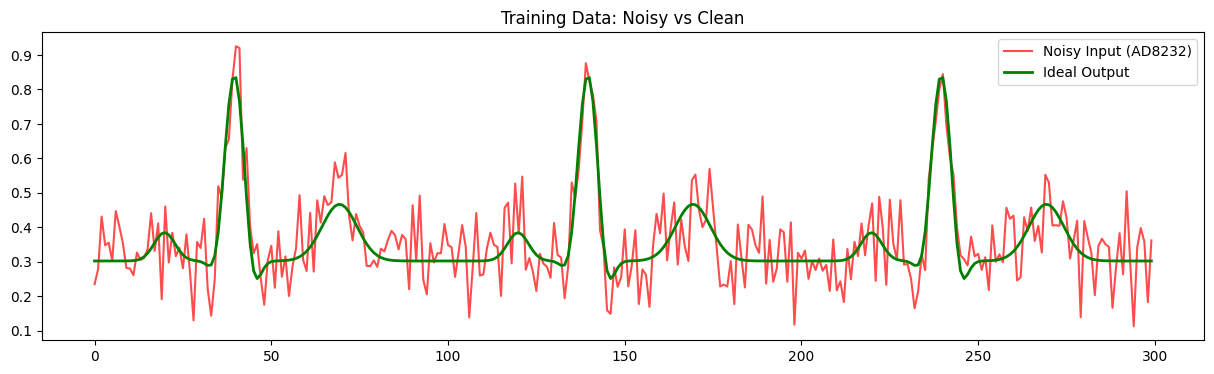

In [ ]:
# -*- coding: utf-8 -*-
# """Bare_Model_AI.ipynb
# Automatically generated by Colab.
# Original file is located at https://colab.research.google.com/drive/14vx7Krma2ucw9minLf2HU4TfW3A7VH3V
# """

import numpy as np # Import numpy for numerical calculations and array handling
import matplotlib.pyplot as plt # Import pyplot for plotting graphs and visualizations

# 1. Configuration
FS = 100            # Set Sampling Rate to 100Hz (Standard low rate for AD8232 sensors)
DURATION = 60       # Set the total duration of the data to 60 seconds
WINDOW_SIZE = 32    # Set the input size for the AI model (kept small for PIC24 memory constraints)

# 2. Function to generate a synthetic single heartbeat (P-QRS-T)
def simulate_heartbeat(t):
    """Generates a synthetic single heartbeat (P-QRS-T wave) for a given time array."""
    # A mix of Gaussian functions to simulate P, Q, R, S, T waves
    p_wave = 0.15 * np.exp(-((t - 0.2)**2) / (2 * 0.03**2)) # Generate P-wave using a Gaussian curve
    q_wave = -0.15 * np.exp(-((t - 0.35)**2) / (2 * 0.02**2)) # Generate Q-wave (dip) using a Gaussian curve
    r_wave = 1.0 * np.exp(-((t - 0.4)**2) / (2 * 0.03**2)) # Generate R-wave (peak) using a Gaussian curve
    s_wave = -0.25 * np.exp(-((t - 0.45)**2) / (2 * 0.02**2)) # Generate S-wave (dip) using a Gaussian curve
    t_wave = 0.3 * np.exp(-((t - 0.7)**2) / (2 * 0.05**2)) # Generate T-wave (recovery) using a Gaussian curve
    return p_wave + q_wave + r_wave + s_wave + t_wave # Sum all waves to create a full heartbeat

# 3. Generate continuous ECG stream
time_steps = np.linspace(0, 1, FS)  # Create a time array from 0 to 1 second with 100 steps
one_beat = simulate_heartbeat(time_steps) # Generate one heartbeat signal using the time steps
# Repeat the beat to create a long signal
clean_signal = np.tile(one_beat, DURATION) # Repeat the single beat 60 times to make a full minute signal

# 4. Add Noise (Simulating Muscle/Movement noise)
noise_level = 0.15 # Set the standard deviation for the noise
noise = np.random.normal(0, noise_level, clean_signal.shape) # Generate random gaussian noise matching the signal shape
noisy_signal = clean_signal + noise # Add the noise to the clean signal to create the input data

# 5. Normalize (Critical for AI: Keep values between 0 and 1)
# We assume the ADC reads 0-3.3V, but we normalize math to 0.0-1.0
min_val = np.min(noisy_signal) # Find the minimum value in the noisy signal
max_val = np.max(noisy_signal) # Find the maximum value in the noisy signal

clean_signal = (clean_signal - min_val) / (max_val - min_val) # Scale clean signal to range 0-1
noisy_signal = (noisy_signal - min_val) / (max_val - min_val) # Scale noisy signal to range 0-1

# Clip to ensure 0-1 range after normalization
clean_signal = np.clip(clean_signal, 0, 1) # Force any values outside 0-1 range to be exactly 0 or 1
noisy_signal = np.clip(noisy_signal, 0, 1) # Force any values outside 0-1 range to be exactly 0 or 1

# Visualize
plt.figure(figsize=(15, 4)) # Create a plot figure with specific size
plt.plot(noisy_signal[:300], label="Noisy Input (AD8232)", color='red', alpha=0.7) # Plot first 300 points of noisy data in red
plt.plot(clean_signal[:300], label="Ideal Output", color='green', linewidth=2) # Plot first 300 points of clean data in green
plt.title("Training Data: Noisy vs Clean") # Set the title of the plot
plt.legend() # Add a legend to the plot
plt.show() # Display the plot

In [ ]:
# Function to chop signal into windows
def create_dataset(signal, window_size):
    """Creates a dataset of sliding windows from a given signal."""
    X = [] # Initialize an empty list to hold the windows
    for i in range(len(signal) - window_size): # Loop through the signal, stopping before the end
        X.append(signal[i : i + window_size]) # Slice a window of data and add it to the list
    return np.array(X) # Convert the list of windows into a numpy array

# Create Training Data
X_noisy = create_dataset(noisy_signal, WINDOW_SIZE) # Create dataset from noisy signal (Input)
X_clean = create_dataset(clean_signal, WINDOW_SIZE) # Create dataset from clean signal (Target)

# Shuffle data for better training
indices = np.arange(X_noisy.shape[0]) # Create an array of indices covering the dataset size
np.random.shuffle(indices) # Randomly shuffle the indices array
X_noisy = X_noisy[indices] # Reorder noisy data using shuffled indices
X_clean = X_clean[indices] # Reorder clean data using the same shuffled indices

print(f"Training Shapes: Input {X_noisy.shape}, Target {X_clean.shape}") # Print the dimensions of the datasets

Training Shapes: Input (5968, 32), Target (5968, 32)


Starting Training...
Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0940 - val_loss: 0.0141
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0124 - val_loss: 0.0105
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0101 - val_loss: 0.0086
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0081 - val_loss: 0.0066
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062 - val_loss: 0.0053
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041 - val_loss: 0.0038
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 9/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 10/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 11/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 12/20
150/150 ━━━━━━━━━━━

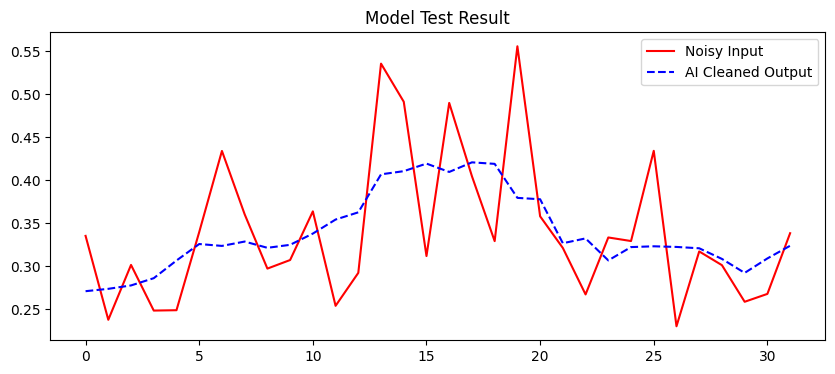

In [ ]:
import tensorflow as tf # Import TensorFlow library
from tensorflow.keras.models import Sequential # Import Sequential model class
from tensorflow.keras.layers import Dense, Input # Import Dense and Input layers

# 1. Define Model (Tiny for PIC24)
model = Sequential([ # Initialize a Sequential model container
    Input(shape=(WINDOW_SIZE,)),      # Define input layer expecting 32 floats (WINDOW_SIZE)
    Dense(16, activation='relu'),     # Add a hidden layer with 16 neurons (Encoder) using ReLU
    Dense(WINDOW_SIZE, activation='linear') # Add output layer with 32 neurons (Decoder) to reconstruct signal
])

# 2. Compile
model.compile(optimizer='adam', loss='mse') # Compile model using Adam optimizer and Mean Squared Error loss

# 3. Train
print("Starting Training...") # Print a status message
history = model.fit( # Start the training process
    X_noisy, X_clean, # Pass in the input (noisy) and target (clean) data
    epochs=20, # Train for 20 iterations over the dataset
    batch_size=32, # Update weights after every 32 samples
    validation_split=0.2, # Use 20% of data for validation (checking performance)
    verbose=1 # Show progress bar during training
)

# 4. Test on a new simulated sample
test_noise = X_noisy[0:1] # Select the first window from the noisy dataset for testing
prediction = model.predict(test_noise) # Run the model to predict the cleaned output

plt.figure(figsize=(10, 4)) # Create a figure for the test result
plt.plot(test_noise[0], label="Noisy Input", color='red') # Plot the noisy input data
plt.plot(prediction[0], label="AI Cleaned Output", color='blue', linestyle='--') # Plot the model's output prediction
plt.title("Model Test Result") # Set title for the plot
plt.legend() # Add a legend
plt.show() # Display the plot

In [ ]:
# Extract weights and biases
# Layer 0 is Dense(16) -> Encoder
# Layer 1 is Dense(32) -> Decoder
weights1, bias1 = model.layers[0].get_weights() # Get weights and biases from the first layer
weights2, bias2 = model.layers[1].get_weights() # Get weights and biases from the second layer

c_code = "" # Initialize an empty string for the C code
c_code += "// ECG AI Model Weights for PIC24\n" # Add a comment header to the C code
c_code += f"#define INPUT_SIZE {WINDOW_SIZE}\n" # Define the input size constant in C
c_code += f"#define HIDDEN_SIZE {weights1.shape[1]}\n\n" # Define the hidden layer size constant in C

def array_to_c(name, data):
    """Converts a numpy array into a C-style float array string."""
    # Flatten array and format as C string
    flat = data.flatten() # Flatten the multidimensional array to 1D
    c_str = ", ".join(f"{x:.5f}" for x in flat) # Format each number to 5 decimals and join with commas
    return f"const float {name}[] = {{{c_str}}};\n" # Return the formatted C array declaration

# Note: Keras weights are [Input, Output], but for standard C loops
# it's often easier to think [Output, Input] or handle indexing carefully.
# We will dump them exactly as Keras stores them (Input x Output)
# and handle the math in C.

c_code += array_to_c("W1", weights1) # Convert first layer weights to C syntax
c_code += array_to_c("B1", bias1)    # Convert first layer biases to C syntax
c_code += array_to_c("W2", weights2) # Convert second layer weights to C syntax
c_code += array_to_c("B2", bias2)    # Convert second layer biases to C syntax

# Save to file
with open("model_weights.h", "w") as f: # Open a file named 'model_weights.h' for writing
    f.write(c_code) # Write the generated C code string to the file

print("SUCCESS! 'model_weights.h' generated.") # Print success message
print("Copy the contents below into your MPLAB X project:") # Print instruction for the user
print("-" * 30) # Print a separator line
print(c_code[:500] + "\n... [truncated] ...") # Print the first 500 characters of the C code as a preview

SUCCESS! 'model_weights.h' generated.
Copy the contents below into your MPLAB X project:
------------------------------
// ECG AI Model Weights for PIC24
#define INPUT_SIZE 32
#define HIDDEN_SIZE 16

const float W1[] = {0.06496, -0.08094, 0.05168, -0.04924, 0.01638, 0.07023, -0.12992, -0.01501, 0.02370, 0.18380, -0.20480, -0.12245, 0.27665, -0.23373, -0.22783, 0.12943, 0.15257, -0.08321, 0.00992, -0.07219, -0.04617, 0.17092, 0.18564, -0.13363, 0.00676, 0.24217, -0.18343, 0.07088, 0.26964, -0.25082, -0.01149, -0.24529, 0.21759, 0.21651, 0.02603, -0.04857, 0.25895, -0.04314, -0.09639, -0.03328, -0.04356, 0.10735, -
... [truncated] ...
